In [1]:
import pandas as pd
import numpy as np
from Autograd import Tensor
import matplotlib.pyplot as plt
from Model import Linear,Sequential
from Activation import ReLU
from Loss import cross_entropy_one_hot, mean_squared_error
from Training import training
from Data import testing_data_processing, training_data_processing
from Testing import classification_accuracy
from Optimiser import SGD

Multilayer Perceptron (MLP) is a simple type of neural network consisting of an input layer, hidden layers and the output layer. It consists of a linear layer, then an activation function applied to the output of the linear layer. This is repeated for each hidden layer. The linear layers have parameters as like in logistic regression or linear regression.

The linear layers on their own would result in just another linear model (like linear regression or logistic regression); this can be seen by just writing the output in terms of the inputs and weights matrices. The introduction of an activation function allows non-linear relationships to be learned, unlike the previous models.

As before, the parameter optimisation is done through gradient descent. The loss function used depends on the desired problem. I attempted to do classifcation using my MLP so cross entropy loss was my loss function. The dataset details and data processing done is identical to that which I did for logistic regression.

I have used the basic autograd engine i created.



In [2]:
normalisedfeatures,price_range,columnmean,columnstd,nofeatures,noclasses,nosamples=training_data_processing()

Their are a variety of choices when it comes to activations the some notable ones being:

\begin{equation}
    ReLU(x)=max(0,x)
\end{equation}

\begin{equation}
    tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}
\end{equation}

These come with some complications. tanh has a vanishing gradient as $x \to \infty$ which cause complications during gradient descent (parameters appear to get 'stuck' as the updates become incredibly small). ReLU overcomes this as the gradient is 1 for x>0, however, for negative values the output is zero, resulting in a 0 gradient. If a node always produces negative outputs it becomes redundant. The use of ReLU can mitigate the vanishing gradient issue, hence potentially accelerating rate of convergence.

When initialising the linear layer parameters, I used Xavier initialisation where we initialise using a normal matrix with mean zero and std=$\sqrt{\frac{2}{n_{in}+n_{out}}}$. Empirically, this initialisation method has shown to yield in non vanishing and non exploding gradients of the loss function. This is because it is designed to keep the variance of the output of each layer roughly constant. 

In a previous experiment I found that initialising using standard normal matrix resulted in 0.29 accuracy compared to 0.92 when using Xavier initialisation; the performance different is evident in this classification task.

The use of activations also introducies another potential issue in optimisation. Our loss function is no longer guaranteed to be convex; this means that there is no longer a unique global minimum with grad=0, but rather there could be local minima, local maxima or saddle points. Getting 'stuck' at these stationary points can result in the model getting unoptimised parameters and hence yielding low accuracy results.

Mini-batch stochastic gradient descent (SGD) works similarly to full-batch gradient descent (GD) but rather than calculating the grad of the loss function on the whole data set, we use the grad of the loss function on a small subset of the full data set to approximate the grad of the full loss. We can think of the SGD loss as an estimate of the GD loss plus some noise, the noise can 'push' the loss out of a saddle point whilst GD would get stuck at the saddle point. I have implemented both below.

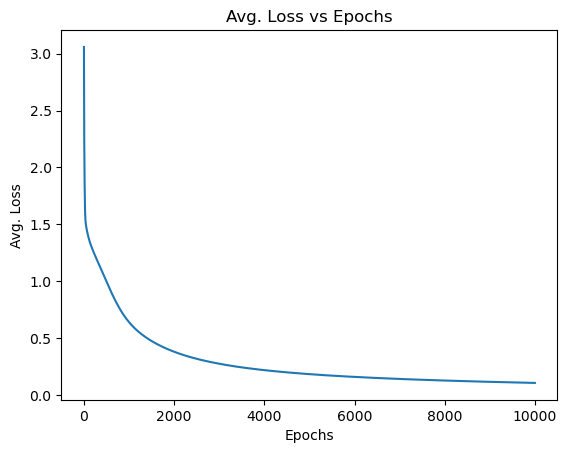

In [3]:
GD_model=Sequential([Linear(nofeatures,20),ReLU(),Linear(20,10),ReLU(),Linear(10,noclasses)])
loss_fn=cross_entropy_one_hot
opti=SGD(GD_model.parameters(),0.005)
GD_losses=training(normalisedfeatures,GD_model,price_range,loss_fn,10000,opti,nosamples)
plt.plot(GD_losses)
plt.xlabel("Epochs")
plt.ylabel("Avg. Loss")
plt.title("Avg. Loss vs Epochs")
plt.show()

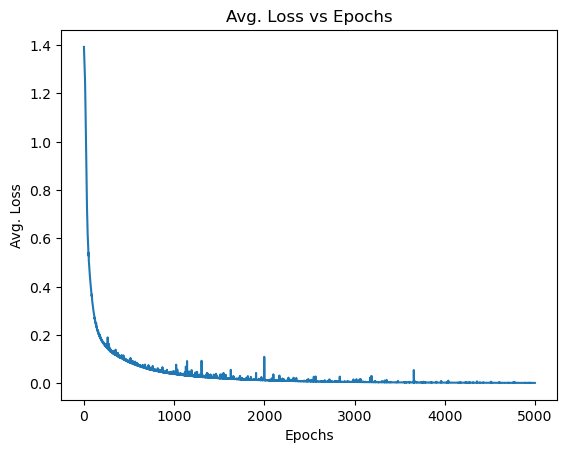

In [4]:
SGD_model=Sequential([Linear(nofeatures,20),ReLU(),Linear(20,10),ReLU(),Linear(10,noclasses)])
loss_fn=cross_entropy_one_hot
opti=SGD(SGD_model.parameters(),0.01)
SGD_losses=training(normalisedfeatures,SGD_model,price_range,loss_fn,5000,opti,100)
plt.plot(SGD_losses)
plt.xlabel("Epochs")
plt.ylabel("Avg. Loss")
plt.title("Avg. Loss vs Epochs")
plt.show()

In the above loss curves, we can see that the average loss in each epoch tends to zero. The SGD loss curve is noticably more noisy, which is to be expected by the nature of estimating the grad of the full loss by a small samples. In the below testing, both models have fairly good accuracy >0.9. SGD has a slightly lower accuracy. The accuracy gained may be affected by the number of iterations and learning rate used. These are both less than the logistic regression accuracy I achieved of 0.96, this could be because the original data was a classification problem well suited for a linear decision boundary, in which case introducing non-linearity would likely overfit.

Below we can see the training data set accuracy. These results imply that the MLP has overfit.

In [5]:
GD_pred=(GD_model.forward_prop(normalisedfeatures)).softmax(axis=1)
GD_prop=classification_accuracy(GD_pred,price_range)

SGD_pred=(SGD_model.forward_prop(normalisedfeatures)).softmax(axis=1)
SGD_prop=classification_accuracy(SGD_pred,price_range)

print(GD_prop, "\n",SGD_prop)

0.97010550996483 
 1.0


In [6]:
normalised,y=testing_data_processing(columnmean,columnstd)

In [7]:
GD_pred=(GD_model.forward_prop(normalised)).softmax(axis=1)
GD_prop=classification_accuracy(GD_pred,y)

SGD_pred=(SGD_model.forward_prop(normalised)).softmax(axis=1)
SGD_prop=classification_accuracy(SGD_pred,y)

print(GD_prop, "\n",SGD_prop)

0.9013605442176871 
 0.9455782312925171
